##### Imports

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import cv2
import tensorflow as tf

from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential

2026-05-16 12:10:47.738287: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1778933447.760965    2927 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1778933447.768509    2927 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1778933447.790618    2927 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778933447.790643    2927 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778933447.790648    2927 computation_placer.cc:177] computation placer alr

In [2]:
print("TensorFlow Version:", tf.__version__)

TensorFlow Version: 2.19.0


In [3]:
print("GPU Available:", tf.config.list_physical_devices('GPU'))

GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


##### Constants

In [4]:
# Image Configuration
IMAGE_SIZE = 224
BATCH_SIZE = 32

# Training Configuration
EPOCHS = 25

# Dataset Paths
TRAIN_DIR = "/kaggle/input/datasets/abilash2025/epic-and-cscr-hospital-dataset/Epic and CSCR hospital Dataset/Train"
TEST_DIR = "/kaggle/input/datasets/abilash2025/epic-and-cscr-hospital-dataset/Epic and CSCR hospital Dataset/Test"

# Class Names
CLASS_NAMES = [
    "glioma",
    "meningioma",
    "pituitary",
    "notumor"
]

NUM_CLASSES = len(CLASS_NAMES)

##### Dataset Verification

In [5]:
for class_name in CLASS_NAMES:
    class_path = os.path.join(TRAIN_DIR, class_name)
    print(f"{class_name}: {len(os.listdir(class_path))} images")

glioma: 3018 images
meningioma: 2183 images
pituitary: 2145 images
notumor: 1945 images


##### Visualize sample images

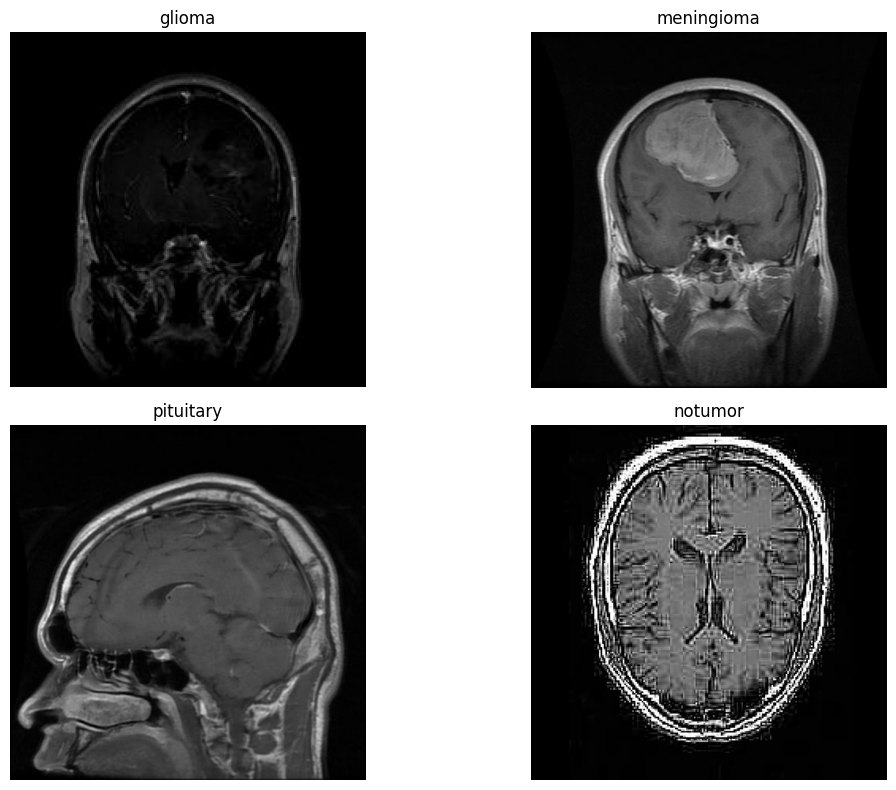

In [6]:
plt.figure(figsize=(12, 8))

for i, class_name in enumerate(CLASS_NAMES):

    class_path = os.path.join(TRAIN_DIR, class_name)

    image_name = os.listdir(class_path)[0]

    image_path = os.path.join(class_path, image_name)

    image = cv2.imread(image_path)

    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    plt.subplot(2, 2, i + 1)

    plt.imshow(image)

    plt.title(class_name)

    plt.axis("off")

plt.tight_layout()

plt.show()

##### Dataset Loaders

In [7]:
train_dataset = tf.keras.preprocessing.image_dataset_from_directory(
    TRAIN_DIR,
    validation_split=0.2,
    subset="training",
    seed=42,
    image_size=(IMAGE_SIZE, IMAGE_SIZE),
    batch_size=BATCH_SIZE
)

validation_dataset = tf.keras.preprocessing.image_dataset_from_directory(
    TRAIN_DIR,
    validation_split=0.2,
    subset="validation",
    seed=42,
    image_size=(IMAGE_SIZE, IMAGE_SIZE),
    batch_size=BATCH_SIZE
)

test_dataset = tf.keras.preprocessing.image_dataset_from_directory(
    TEST_DIR,
    image_size=(IMAGE_SIZE, IMAGE_SIZE),
    batch_size=BATCH_SIZE,
    shuffle=False
)

Found 9291 files belonging to 4 classes.
Using 7433 files for training.


I0000 00:00:1778933463.104778    2927 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1778933463.109954    2927 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Found 9291 files belonging to 4 classes.
Using 1858 files for validation.
Found 1857 files belonging to 4 classes.


##### Verifying class mapping

In [8]:
class_names = train_dataset.class_names
print("Class Names:", class_names)

Class Names: ['glioma', 'meningioma', 'notumor', 'pituitary']


##### Normalization Layer

In [9]:
normalization_layer = layers.Rescaling(1.0 / 255)

##### Data Augmentation

In [10]:
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
    layers.RandomContrast(0.1)
])

##### Optimize Dataset Performance

In [11]:
AUTOTUNE = tf.data.AUTOTUNE

train_dataset = train_dataset.prefetch(buffer_size=AUTOTUNE)

validation_dataset = validation_dataset.prefetch(buffer_size=AUTOTUNE)

test_dataset = test_dataset.prefetch(buffer_size=AUTOTUNE)

##### Vizualise Augmented Images

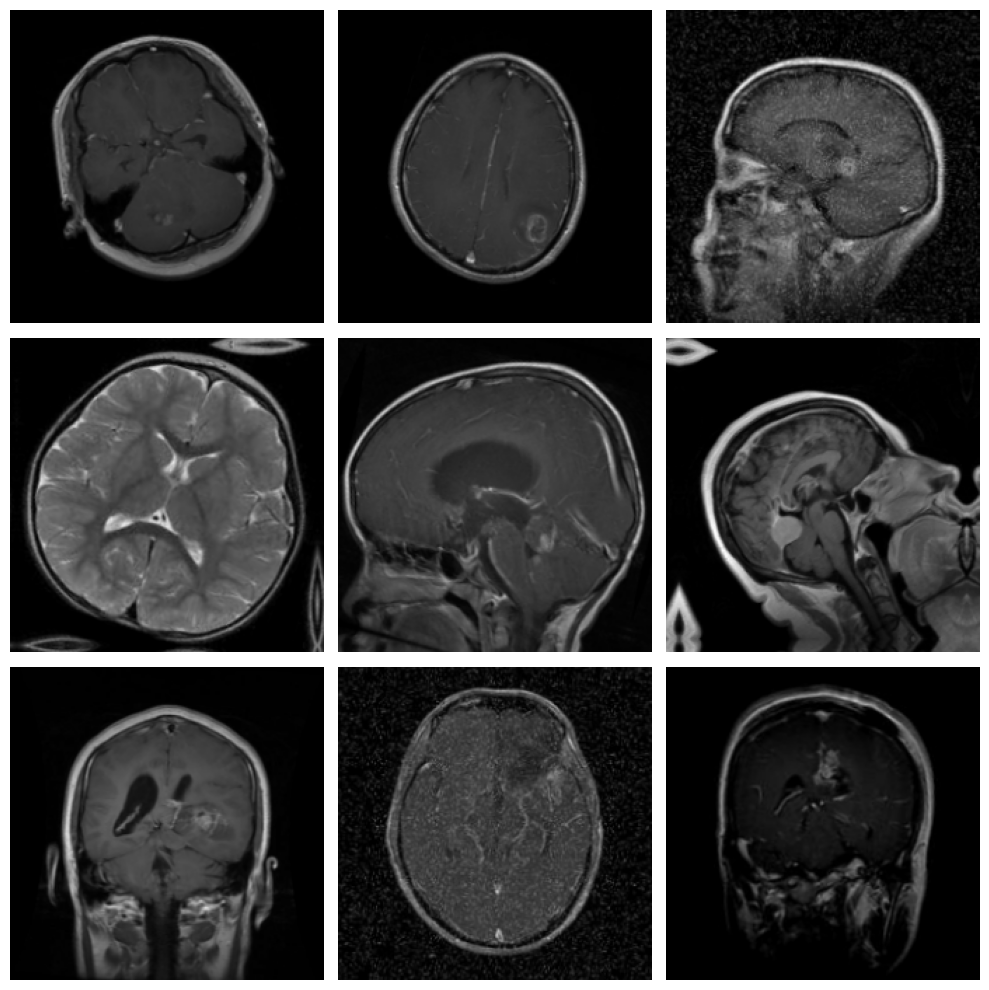

In [12]:
plt.figure(figsize=(10, 10))

for images, labels in train_dataset.take(1):

    augmented_images = data_augmentation(images)

    for i in range(9):

        ax = plt.subplot(3, 3, i + 1)

        plt.imshow(augmented_images[i].numpy().astype("uint8"))

        plt.axis("off")

plt.tight_layout()

plt.show()

##### CNN Architecture

In [13]:
model = keras.Sequential([

    # Data Augmentation
    data_augmentation,

    # Normalization
    normalization_layer,

    # -------------------------------
    # Conv Block 1
    # -------------------------------
    layers.Conv2D(
        32,
        (3, 3),
        activation='relu',
        padding='same',
        input_shape=(IMAGE_SIZE, IMAGE_SIZE, 3)
    ),

    layers.MaxPooling2D((2, 2)),

    # -------------------------------
    # Conv Block 2
    # -------------------------------
    layers.Conv2D(
        64,
        (3, 3),
        activation='relu',
        padding='same'
    ),

    layers.MaxPooling2D((2, 2)),

    # -------------------------------
    # Conv Block 3
    # -------------------------------
    layers.Conv2D(
        128,
        (3, 3),
        activation='relu',
        padding='same'
    ),

    layers.MaxPooling2D((2, 2)),

    # -------------------------------
    # Conv Block 4
    # -------------------------------
    layers.Conv2D(
        256,
        (3, 3),
        activation='relu',
        padding='same',
        name="last_conv_layer"
    ),

    layers.MaxPooling2D((2, 2)),

    # -------------------------------
    # Classification Head
    # -------------------------------
    layers.GlobalAveragePooling2D(),

    layers.Dense(
        128,
        activation='relu'
    ),

    layers.Dropout(0.5),

    layers.Dense(
        NUM_CLASSES,
        activation='softmax'
    )
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [14]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (32, 224, 224, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (32, 224, 224, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (32, 224, 224, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (32, 112, 112, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (32, 112, 112, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (32, 56, 56, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (32, 56, 56, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (32, 28, 28, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ last_conv_layer (Conv2D)        │ (32, 28, 28, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (32, 14, 14, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (32, 256)              │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (32, 128)              │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (32, 128)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (32, 4)                │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 421,828 (1.61 MB)

 Trainable params: 421,828 (1.61 MB)

 Non-trainable params: 0 (0.00 B)

##### Compile the model

In [15]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

##### Set up callbacks

In [16]:
early_stopping = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

model_checkpoint = keras.callbacks.ModelCheckpoint(
    filepath='brain_tumor_cnn.keras',
    monitor='val_accuracy',
    save_best_only=True
)

reduce_lr = keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,
    patience=3,
    min_lr=1e-6
)

##### Train the model

In [17]:
history = model.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=EPOCHS,
    callbacks=[
        early_stopping,
        model_checkpoint,
        reduce_lr
    ]
)

Epoch 1/25


I0000 00:00:1778933471.633229    3003 cuda_dnn.cc:529] Loaded cuDNN version 91002


233/233 ━━━━━━━━━━━━━━━━━━━━ 19s 60ms/step - accuracy: 0.3802 - loss: 1.3081 - val_accuracy: 0.4177 - val_loss: 1.3419 - learning_rate: 0.0010
Epoch 2/25
233/233 ━━━━━━━━━━━━━━━━━━━━ 14s 58ms/step - accuracy: 0.5178 - loss: 1.1155 - val_accuracy: 0.5404 - val_loss: 1.1384 - learning_rate: 0.0010
Epoch 3/25
233/233 ━━━━━━━━━━━━━━━━━━━━ 14s 58ms/step - accuracy: 0.5876 - loss: 1.0078 - val_accuracy: 0.6491 - val_loss: 0.8895 - learning_rate: 0.0010
Epoch 4/25
233/233 ━━━━━━━━━━━━━━━━━━━━ 14s 58ms/step - accuracy: 0.6384 - loss: 0.8916 - val_accuracy: 0.6270 - val_loss: 0.9150 - learning_rate: 0.0010
Epoch 5/25
233/233 ━━━━━━━━━━━━━━━━━━━━ 14s 59ms/step - accuracy: 0.6613 - loss: 0.8509 - val_accuracy: 0.6550 - val_loss: 0.8292 - learning_rate: 0.0010
Epoch 6/25
233/233 ━━━━━━━━━━━━━━━━━━━━ 14s 60ms/step - accuracy: 0.6927 - loss: 0.7687 - val_accuracy: 0.7034 - val_loss: 0.7952 - learning_rate: 0.0010
Epoch 7/25
233/233 ━━━━━━━━━━━━━━━━━━━━ 14s 60ms/step - accuracy: 0.7104 - loss: 0.7358

##### Visualize Training Performance

In [18]:
accuracy = history.history['accuracy']
val_accuracy = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(len(accuracy))

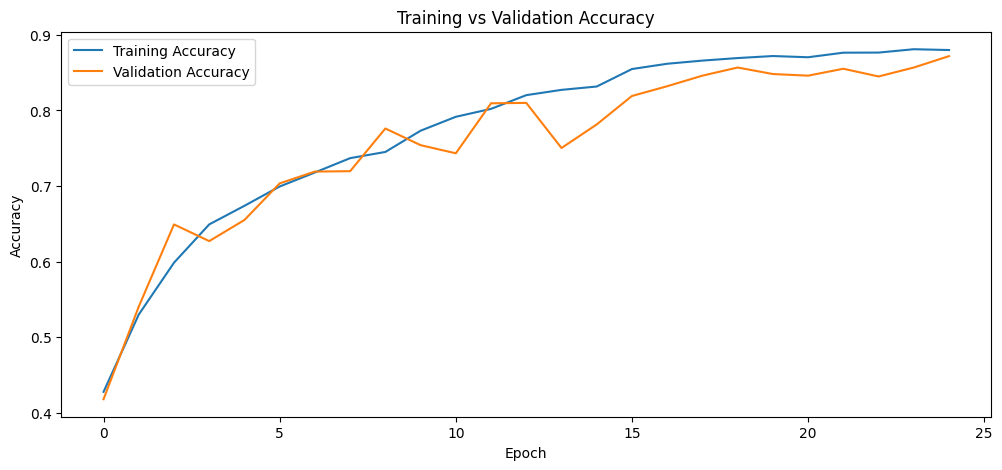

In [19]:
plt.figure(figsize=(12, 5))

plt.plot(epochs_range, accuracy, label='Training Accuracy')

plt.plot(epochs_range, val_accuracy, label='Validation Accuracy')

plt.legend()

plt.title('Training vs Validation Accuracy')

plt.xlabel('Epoch')

plt.ylabel('Accuracy')

plt.show()

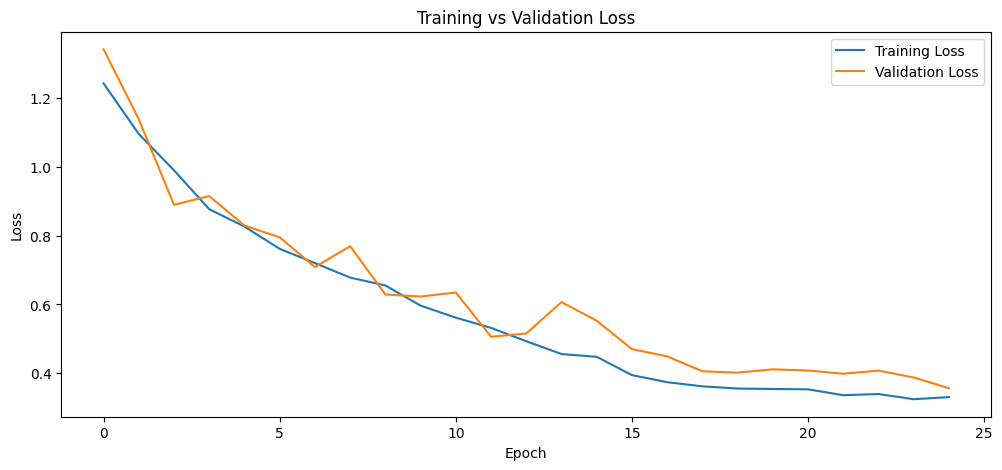

In [20]:
plt.figure(figsize=(12, 5))

plt.plot(epochs_range, loss, label='Training Loss')

plt.plot(epochs_range, val_loss, label='Validation Loss')

plt.legend()

plt.title('Training vs Validation Loss')

plt.xlabel('Epoch')

plt.ylabel('Loss')

plt.show()

##### Import Evaluation Libraries

In [21]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix
)

import seaborn as sns

##### Evaluate Test Accuracy

In [22]:
test_loss, test_accuracy = model.evaluate(test_dataset)

print(f"Test Accuracy: {test_accuracy:.4f}")

print(f"Test Loss: {test_loss:.4f}")

59/59 ━━━━━━━━━━━━━━━━━━━━ 2s 27ms/step - accuracy: 0.7620 - loss: 0.5328
Test Accuracy: 0.8008
Test Loss: 0.4658


##### Generate Predictions

In [23]:
predictions = model.predict(test_dataset)

#Convert Probabilities to Labels
predicted_labels = np.argmax(predictions, axis=1)

#Extract True Labels
true_labels = np.concatenate([
    labels.numpy()
    for _, labels in test_dataset
])

59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step


##### Generate Classification Report

In [24]:
report = classification_report(
    true_labels,
    predicted_labels,
    target_names=class_names
)

print(report)

              precision    recall  f1-score   support

      glioma       0.90      0.72      0.80       603
  meningioma       0.67      0.57      0.62       436
     notumor       0.88      0.97      0.92       389
   pituitary       0.74      0.99      0.85       429

    accuracy                           0.80      1857
   macro avg       0.80      0.81      0.80      1857
weighted avg       0.81      0.80      0.79      1857



##### Create Confusion Matrix

In [25]:
cm = confusion_matrix(
    true_labels,
    predicted_labels
)

##### Visualize Confusion Matrix

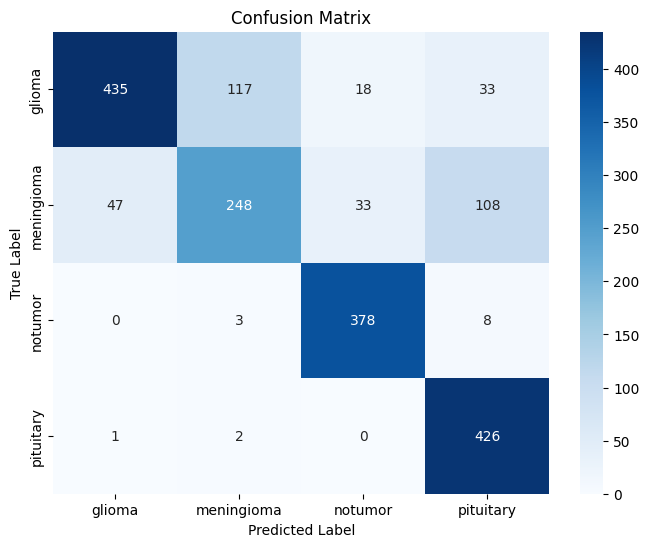

In [26]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted Label")

plt.ylabel("True Label")

plt.title("Confusion Matrix")

plt.show()

##### Analyze Misclassified Images

In [27]:
misclassified_images = []
misclassified_true = []
misclassified_pred = []

for images, labels in test_dataset:

    preds = model.predict(images, verbose=0)

    pred_labels = np.argmax(preds, axis=1)

    for i in range(len(labels)):

        if labels[i] != pred_labels[i]:

            misclassified_images.append(images[i].numpy().astype("uint8"))

            misclassified_true.append(labels[i].numpy())

            misclassified_pred.append(pred_labels[i])

##### Visualize Misclassified Examples

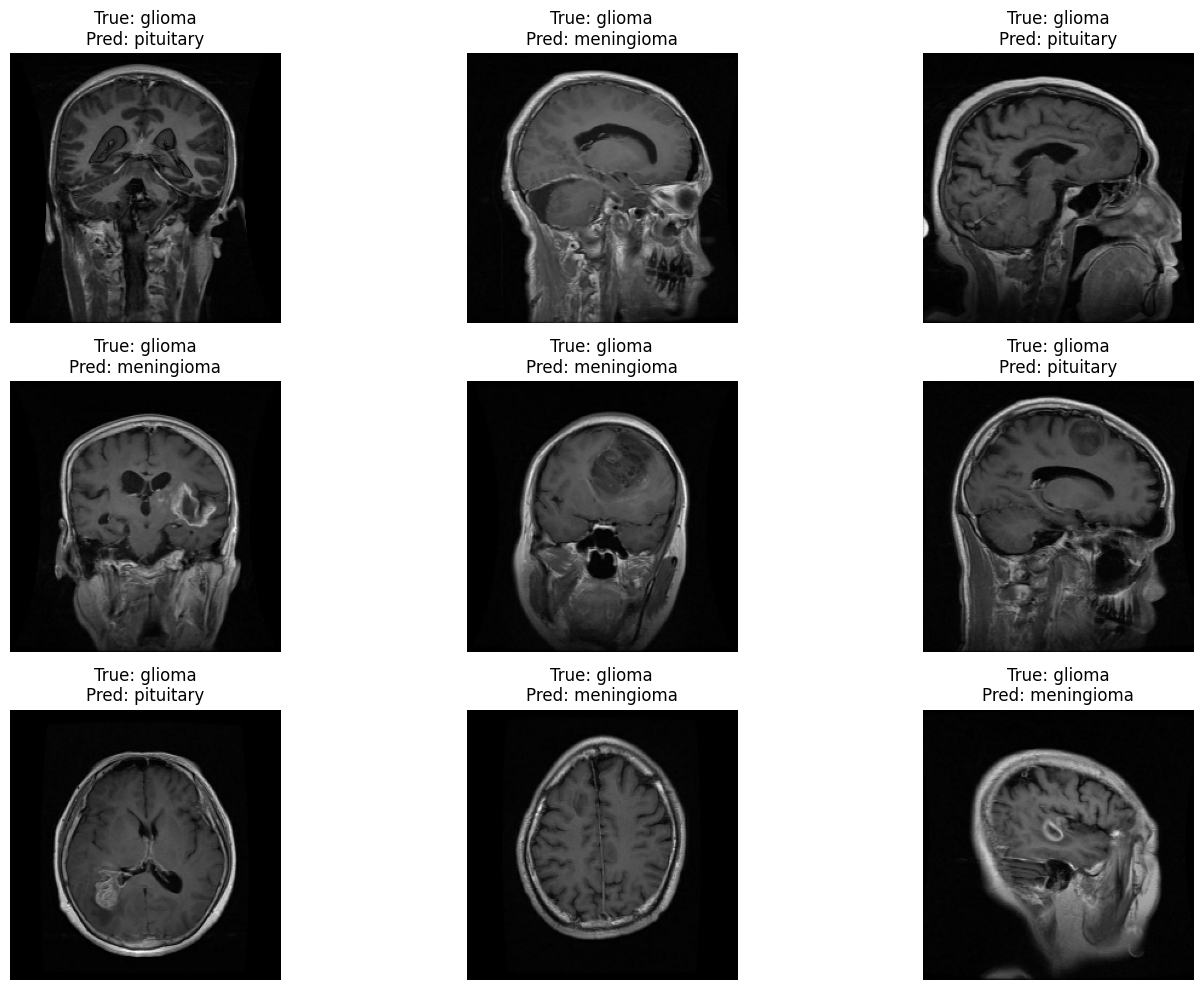

In [28]:
plt.figure(figsize=(15, 10))

for i in range(min(9, len(misclassified_images))):

    plt.subplot(3, 3, i + 1)

    plt.imshow(misclassified_images[i])

    true_class = class_names[
        misclassified_true[i]
    ]

    predicted_class = class_names[
        misclassified_pred[i]
    ]

    plt.title(
        f"True: {true_class}\nPred: {predicted_class}"
    )

    plt.axis("off")

plt.tight_layout()

plt.show()

##### Grad-CAM

In [33]:
#Creating a Grad-CAM function

def make_gradcam_heatmap(
    image_batch,
    model,
    last_conv_layer_name
):

    # Create Grad-CAM model
    grad_model = tf.keras.models.Model(
        inputs=model.inputs,
        outputs=[
            model.get_layer(last_conv_layer_name).output,
            model.outputs[0]
        ]
    )

    # Record gradients
    with tf.GradientTape() as tape:

        conv_outputs, predictions = grad_model(image_batch)

        predicted_class_index = tf.argmax(
            predictions[0]
        )

        class_channel = predictions[
            :,
            predicted_class_index
        ]

    # Compute gradients
    gradients = tape.gradient(
        class_channel,
        conv_outputs
    )

    # Average gradients
    pooled_gradients = tf.reduce_mean(
        gradients,
        axis=(0, 1, 2)
    )

    # Remove batch dimension
    conv_outputs = conv_outputs[0]

    # Weight feature maps
    heatmap = conv_outputs @ pooled_gradients[..., tf.newaxis]

    heatmap = tf.squeeze(heatmap)

    # ReLU
    heatmap = tf.maximum(heatmap, 0)

    # Normalize
    heatmap = heatmap / tf.math.reduce_max(heatmap)

    return heatmap.numpy()

In [34]:
#Generate HeatMap

heatmap = make_gradcam_heatmap(
    image_batch,
    model,
    last_conv_layer_name="last_conv_layer"
)

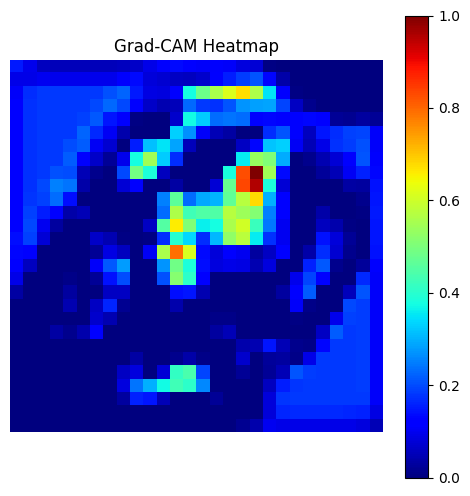

In [35]:
#Visualize HeatMap

plt.figure(figsize=(6, 6))

plt.imshow(heatmap, cmap='jet')

plt.title("Grad-CAM Heatmap")

plt.colorbar()

plt.axis("off")

plt.show()

##### Overlay Visualization


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.380392156862745].


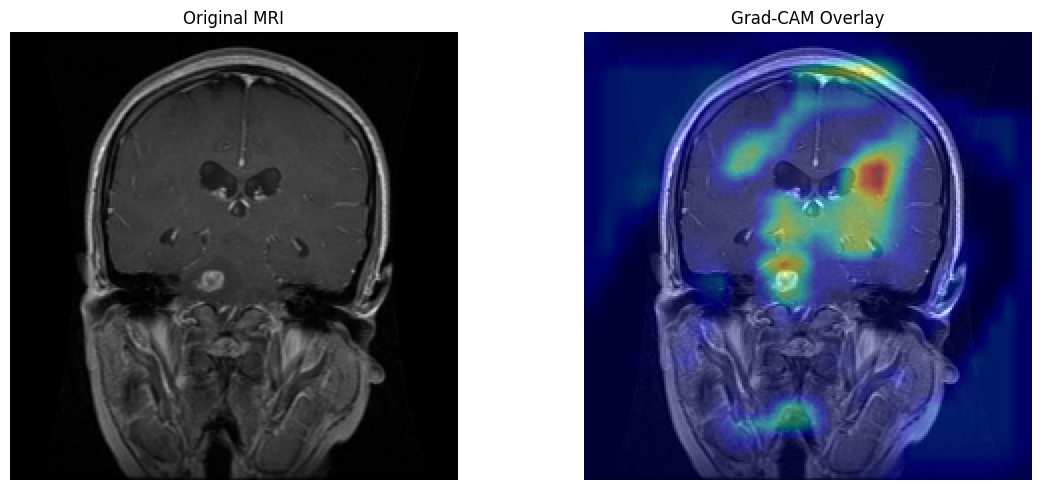

In [ ]:
#OverLay Visualization

import matplotlib.cm as cm

# Convert original image
original_image = image.numpy().astype("uint8")

# Resize heatmap
heatmap_resized = cv2.resize(
    heatmap,
    (IMAGE_SIZE, IMAGE_SIZE)
)

# Convert to RGB heatmap
heatmap_colored = cm.jet(
    heatmap_resized
)[:, :, :3]

# Overlay
superimposed_image = (
    heatmap_colored * 0.4 +
    original_image / 255.0
)

# Plot
plt.figure(figsize=(12, 5))

# Original MRI
plt.subplot(1, 2, 1)

plt.imshow(original_image)

plt.title("Original MRI")

plt.axis("off")

# Grad-CAM Overlay
plt.subplot(1, 2, 2)

plt.imshow(superimposed_image)

plt.title("Grad-CAM Overlay")

plt.axis("off")

plt.tight_layout()

plt.show()

##### Save Model

In [43]:
model.save("brain_tumor_cnn.keras")

### Building Reusable interface functions

##### Final Preprocessing function

In [45]:
def preprocess_image(image_path):

    image = tf.io.read_file(image_path)

    image = tf.image.decode_image(
        image,
        channels=3,
        expand_animations=False
    )

    image = tf.image.resize(
        image,
        [IMAGE_SIZE, IMAGE_SIZE]
    )

    image = tf.cast(image, tf.float32)

    image = tf.expand_dims(
        image,
        axis=0
    )

    return image

##### Final Prediction Function

In [46]:
def predict_image(image_path):

    # Preprocess image
    image_batch = preprocess_image(image_path)

    # Predict
    predictions = model.predict(
        image_batch,
        verbose=0
    )

    # Get predicted class
    predicted_index = np.argmax(predictions[0])

    predicted_class = class_names[predicted_index]

    confidence = float(
        predictions[0][predicted_index]
    )

    return {
        "class": predicted_class,
        "confidence": round(confidence * 100, 2),
        "predictions": predictions[0]
    }

##### Final GradCAM function

In [48]:
def generate_gradcam(
    image_path,
    model,
    last_conv_layer_name="last_conv_layer"
):

    # Preprocess image
    image_batch = preprocess_image(image_path)

    # Grad model
    grad_model = tf.keras.models.Model(
        inputs=model.inputs,
        outputs=[
            model.get_layer(last_conv_layer_name).output,
            model.outputs[0]
        ]
    )

    # Compute gradients
    with tf.GradientTape() as tape:

        conv_outputs, predictions = grad_model(
            image_batch
        )

        predicted_class_index = tf.argmax(
            predictions[0]
        )

        class_channel = predictions[
            :,
            predicted_class_index
        ]

    gradients = tape.gradient(
        class_channel,
        conv_outputs
    )

    pooled_gradients = tf.reduce_mean(
        gradients,
        axis=(0, 1, 2)
    )

    conv_outputs = conv_outputs[0]

    heatmap = conv_outputs @ pooled_gradients[..., tf.newaxis]

    heatmap = tf.squeeze(heatmap)

    heatmap = tf.maximum(heatmap, 0)

    heatmap /= tf.math.reduce_max(heatmap)

    return heatmap.numpy()

##### Final Overlay Function

In [49]:
def create_overlay(image_path, heatmap):

    # Load original image
    image = cv2.imread(image_path)

    image = cv2.cvtColor(
        image,
        cv2.COLOR_BGR2RGB
    )

    image = cv2.resize(
        image,
        (IMAGE_SIZE, IMAGE_SIZE)
    )

    # Resize heatmap
    heatmap = cv2.resize(
        heatmap,
        (IMAGE_SIZE, IMAGE_SIZE)
    )

    # Convert heatmap to RGB
    heatmap_colored = cm.jet(
        heatmap
    )[:, :, :3]

    # Overlay
    overlay = (
        heatmap_colored * 0.4 +
        image / 255.0
    )

    overlay = np.clip(
        overlay,
        0,
        1
    )

    return overlay

{'class': 'glioma', 'confidence': 99.98, 'predictions': array([9.9978751e-01, 2.0149280e-04, 9.2192204e-06, 1.7895368e-06],
      dtype=float32)}


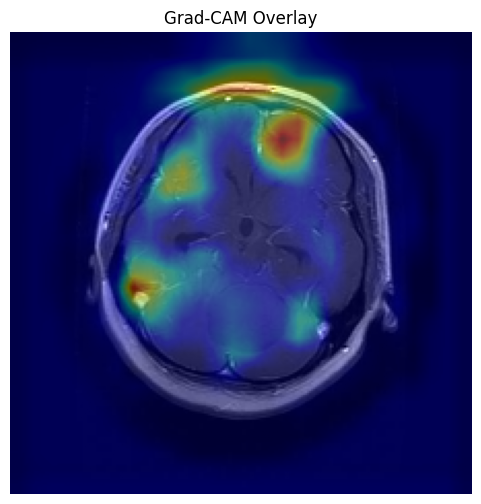

In [50]:
#Pipeline testing

# Prediction
result = predict_image(image_path)

print(result)

# Heatmap
heatmap = generate_gradcam(
    image_path,
    model
)

# Overlay
overlay = create_overlay(
    image_path,
    heatmap
)

# Display
plt.figure(figsize=(6, 6))

plt.imshow(overlay)

plt.title("Grad-CAM Overlay")

plt.axis("off")

plt.show()